In [ ]:
import os

# Create the kaggle directory and config manually
os.makedirs('/root/.kaggle', exist_ok=True)

#configure kaggle
kaggle_config = {
    "username": "juliusbay",
    "key": "KGAT_4c667dc836ab1fdf1b4cf553d9263f67"
}

import json
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_config, f)

os.chmod('/root/.kaggle/kaggle.json', 0o600)
print("Kaggle configured!")

Kaggle configured!


In [ ]:
# download dataset
!pip install kaggle -q
!kaggle datasets download -d vipoooool/new-plant-diseases-dataset
!unzip -q new-plant-diseases-dataset.zip -d plant_disease_data
print("Done!")

Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset
License(s): copyright-authors
100% 2.70G/2.70G [00:17<00:00, 163MB/s]

Done!


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import numpy as np
import os

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
base_dir = '/content/plant_disease_data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)'
train_dir = os.path.join(base_dir, 'train')
valid_dir = os.path.join(base_dir, 'valid')

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Confirm folders exist
print("Train folder exists:", os.path.exists(train_dir))
print("Valid folder exists:", os.path.exists(valid_dir))

Train folder exists: True
Valid folder exists: True


In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    fill_mode='nearest'
)

valid_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

valid_generator = valid_datagen.flow_from_directory(
    valid_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.


In [ ]:
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(38, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,595,686 (9.90 MB)

 Trainable params: 337,702 (1.29 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-6)
]

history = model.fit(
    train_generator,
    epochs=10,
    validation_data=valid_generator,
    callbacks=callbacks
)

Epoch 1/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 871s 396ms/step - accuracy: 0.9026 - loss: 0.2929 - val_accuracy: 0.9286 - val_loss: 0.2141 - learning_rate: 0.0010
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 860s 391ms/step - accuracy: 0.9067 - loss: 0.2788 - val_accuracy: 0.9347 - val_loss: 0.1956 - learning_rate: 0.0010
Epoch 3/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 863s 393ms/step - accuracy: 0.9078 - loss: 0.2750 - val_accuracy: 0.9390 - val_loss: 0.1836 - learning_rate: 0.0010
Epoch 4/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 866s 394ms/step - accuracy: 0.9145 - loss: 0.2575 - val_accuracy: 0.9358 - val_loss: 0.1923 - learning_rate: 0.0010
Epoch 5/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 868s 395ms/step - accuracy: 0.9162 - loss: 0.2505 - val_accuracy: 0.9300 - val_loss: 0.2056 - learning_rate: 0.0010
Epoch 6/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 852s 388ms/step - accuracy: 0.9368 - loss: 0.1850 - val_accuracy: 0.9479 - val_loss: 0.1524 - learning_rate: 2.0000e-04
Epoch 7/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 859s 3

In [ ]:
model.save('plant_disease_model_v2.keras')
print("Saved!")

Saved!


In [ ]:
from google.colab import files
files.download('plant_disease_model_v2.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
class_names = list(train_generator.class_indices.keys())
print(class_names)

['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Sp

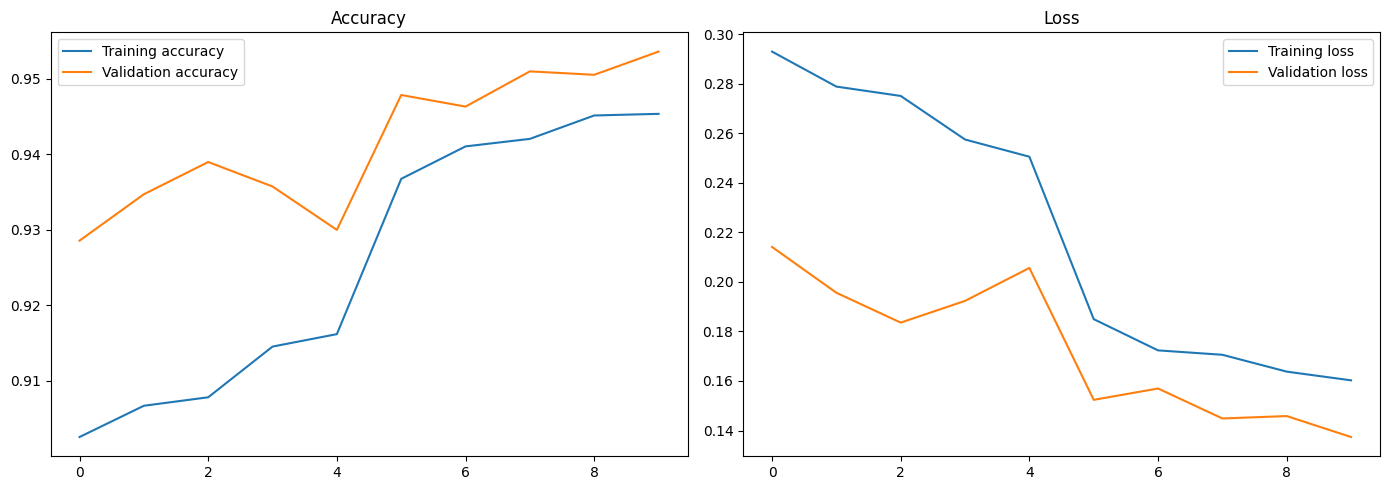

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history.history['accuracy'], label='Training accuracy')
ax1.plot(history.history['val_accuracy'], label='Validation accuracy')
ax1.set_title('Accuracy')
ax1.legend()
ax2.plot(history.history['loss'], label='Training loss')
ax2.plot(history.history['val_loss'], label='Validation loss')
ax2.set_title('Loss')
ax2.legend()
plt.tight_layout()
plt.savefig('training_results.png', dpi=150)
plt.show()

In [ ]:
from google.colab import files
files.download('training_results.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>